Training model accuracy: 0.8013


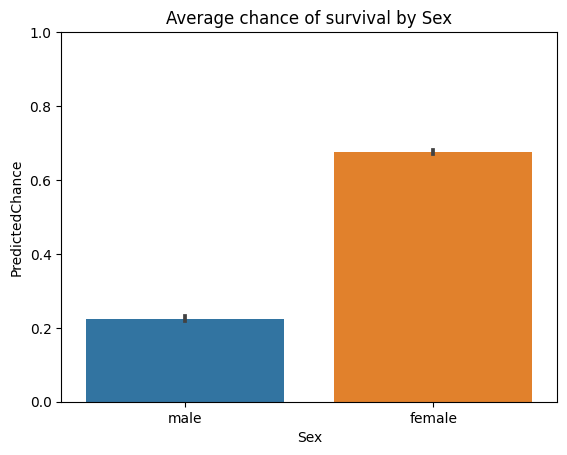

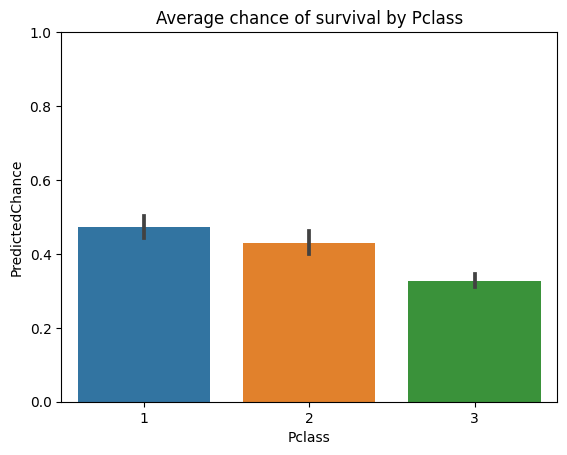

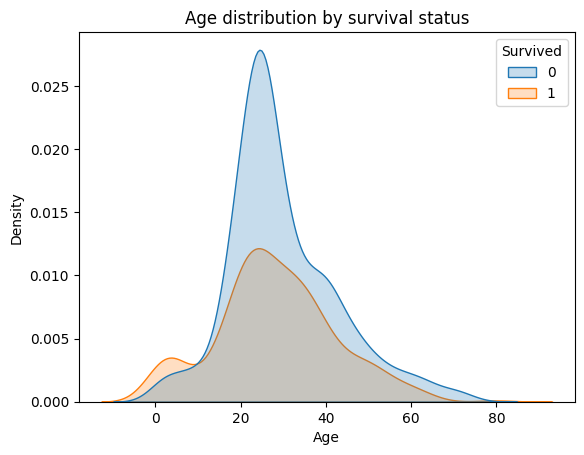

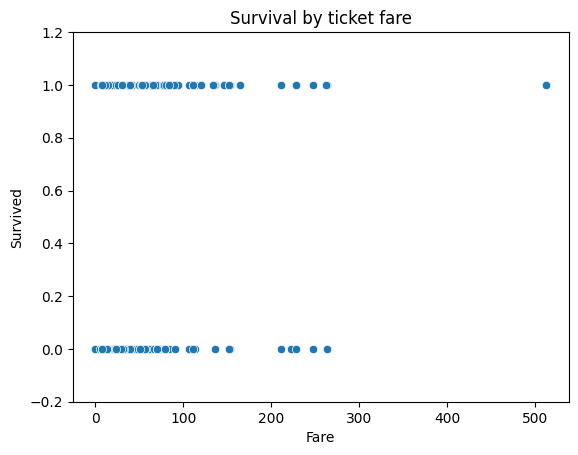

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def load_and_prepare_data(path):
    """Loads, fills and add feature engineering to Titanic dataset"""
    #loads data
    data = pd.read_csv(path)

    #Fill missing age using group-wise median by Sex and Pclass
    data['Age'] = data['Age'].fillna(data.groupby(['Sex', 'Pclass'])['Age'].transform('median'))

    #Fill missing Fare using group-wise median by Pclass
    data['Fare'] = data['Fare'].fillna(data.groupby(['Pclass'])['Fare'].transform('median'))

    #fill the rest of the missing data
    data['Cabin'] = data['Cabin'].fillna('Unknown')
    data['Embarked'] = data['Embarked'].fillna('Unknown')

    #add the new features
    data['FamilySize'] = data['Parch'] + data['SibSp'] + 1
    data['HasCabin'] = data['Cabin'].notnull().astype(int)
    data['FarePerPerson'] = data['Fare'] / data['FamilySize']
    data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)

    return data

def calculate_weights(data, features):
    """Calculates weights of certain feature based on the survival rate difference between smallest and largest group"""
    diffs = {}
    for feature in features:
        if feature not in data.columns:
            continue
        grouped = data.groupby(feature)['Survived'].mean()
        if grouped.empty:
            diffs[feature] = 0
        else:
            diffs[feature] = grouped.max() - grouped.min()
    total = sum(diffs.values()) or 1  # Avoid division by zero
    return {k: v / total for k, v in diffs.items()}

def convert_probs_to_dict(data, features):
    """Convert each category probability value to dictionary"""
    return {feature: data.groupby(feature)['Survived'].mean().to_dict() for feature in features if feature in data.columns}

def weighted_feature_score(row, probs, weights, features):
    """Add weights to specif how important certain feature is"""
    score = 0
    for feature in features:
        score += probs.get(feature, {}).get(row[feature], 0.5) * weights.get(feature, 0)
    return score

def add_survival_predictions(data, probs, weights, features):
    """Add predictions to test.csv file"""
    data['PredictedChance'] = data.apply(
        lambda row: weighted_feature_score(row, probs, weights, features), axis=1)
    return data

def find_best_threshold(data):
    """Find threshold that maximazes accuracy"""
    best_accuracy = 0
    best_threshold = 0.5
    for threshold in np.arange(0.1, 0.9, 0.01):
        predictions = (data['PredictedChance'] >= threshold).astype('int')
        accuracy = (predictions == data['Survived']).mean()
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = threshold
    return best_threshold

def train_model(data, features):
    """Train model by finding most optimal parameters"""
    probs = convert_probs_to_dict(data, features)
    weights = calculate_weights(data, features)
    data = add_survival_predictions(data, probs, weights, features)
    threshold = find_best_threshold(data)
    return probs, weights, threshold, data

def predict_test(data, probs, weights, threshold, features):
    """Predicts survival of test set"""
    test = add_survival_predictions(data, probs, weights, features)
    test['Survived'] = (test['PredictedChance'] >= threshold).astype('int')
    return test[['PassengerId', 'Survived']]

def evaluate_predictions(data, threshold):
    """Prints model accuracy on given data"""
    predictions = (data['PredictedChance'] >= threshold).astype(int)
    actual = data['Survived']
    correct = (predictions == actual).sum()
    total = len(actual)
    accuracy = correct / total
    print(f"Training model accuracy: {accuracy:.4f}")

#draw plots
def plot_predicted_chance(data):
    sns.histplot(data['PredictedChance'], bins = 20, kde = True)
    plt.title("Distribution of predicted survival probability")
    plt.xlabel("Predicted chance")
    plt.ylabel("Number of passengers")
    plt.show()

def plot_feature_vs_prediction(data, column):
    sns.barplot(data = data, x = column, y = 'PredictedChance')
    plt.title(f"Average chance of survival by {column}")
    plt.ylim(0, 1)
    plt.show()

def plot_age_distribution(data):
    sns.kdeplot(data = data, x = 'Age', hue = 'Survived', fill = True)
    plt.title("Age distribution by survival status")
    plt.xlabel("Age")
    plt.ylabel("Density")
    plt.show()

def plot_fare_vs_survival(data):
    sns.scatterplot(data = data, x = 'Fare', y = 'Survived')
    plt.title("Survival by ticket fare")
    plt.xlabel("Fare")
    plt.ylabel("Survived")
    plt.ylim(-0.2, 1.2)
    plt.show()

def main():
    #load data
    train = load_and_prepare_data('/kaggle/input/titanic/train.csv')
    test = load_and_prepare_data('/kaggle/input/titanic/test.csv')

    #define combination of features with highest accuracy
    features = ['Sex', 'Pclass', 'Title']

    #train model
    probs, weights, threshold, train = train_model(train, features)

    #add survival predictions
    submission = predict_test(test, probs, weights, threshold, features)

    #export predicted survival results for test set
    submission.to_csv('submission.csv', index = False)

    #show training prediction accuracy
    evaluate_predictions(train, threshold)

    #plot charts based on features
    for feature in features:
        if feature not in ['Age', 'FarePerPerson', 'Title']:
            plot_feature_vs_prediction(train, feature)

    #plot other charts
    plot_age_distribution(train)
    plot_fare_vs_survival(train)

if __name__ == "__main__":
    main()